### Problem

An electron is initially prepared in a quantum mechanical state with zero average momentum and a wavefunction given by:  

$$
\psi(x, t = 0) \propto e^{-x^2/2a^2}
$$

The potential everywhere is zero. A detector is positioned at distance $x = L$ from the electron’s initial position.

1. After approximately how long is the electron likely to have passed the detector?  
2. Find the probability of observing the electron past $x = L$ as a function of time.

Note: it's convenient to set $\hbar = 1$.

In [1]:
# Import Sympy
import sympy as smp

In [2]:
# Define symbols
x = smp.symbols("x", real = True)
a, L, m = smp.symbols("a L m", real = True, positive = True, constant = True)
t = smp.symbols("t", real = True, nonnegative = True)
k = smp.symbols("k", real = True)

### Point 1

We can estimate the time as the ratio of distance to the electron’s velocity:

$$
T \approx \frac{L}{v}
$$

The velocity, in turn, can be estimated as the ratio of momentum to its mass:

$$
v \approx \frac{P}{m}
$$

Since we are in a state with zero average momentum, we can estimate the momentum as the square root of the mean square momentum in the state $\psi$:

$$
P \approx \sqrt{<P ^ 2>}
$$

Thus we obtain:

$$
T \approx \frac{m L}{\sqrt{<P ^ 2>}}
$$

The mean square momentum in the state $\psi$ is:

$$
<P ^ 2> = - \int_{- \infty}^{\infty} \psi(x, 0) \frac{d ^ 2}{d x ^ 2} \psi(x, 0) \, dx   
$$

In [3]:
# Psi(x, 0)
psi = smp.exp(- x ** 2 / (2 * a ** 2))
psi

exp(-x**2/(2*a**2))

In [4]:
# Normalize psi(x, 0)
psi = smp.sqrt(1 / smp.integrate(psi ** 2, (x, - smp.oo, smp.oo))) * psi
psi

exp(-x**2/(2*a**2))/(pi**(1/4)*sqrt(a))

In [5]:
# Compute P^2 in the state psi(x, 0)
P_squared = - smp.integrate(psi * smp.diff(psi, x, 2), (x, - smp.oo, smp.oo))
P_squared

1/(2*a**2)

In [6]:
# Time
T = m * L / smp.sqrt(P_squared)
T

sqrt(2)*L*a*m

### Point 2

The probability that the electron is found beyond the detector (i.e., at $x > L$) is obtained by integrating the time‑dependent probability density from $L$ to infinity:

$$
    P(x > L,\; t) \;=\; \int_{L}^{\infty} |\psi(x,t)|^{2} \, dx
$$

To compute this we need the explicit form of $|\psi(x,t)|^{2}$. So, let's write $\psi(x, 0)$ as a superposition of plane-wave eigenstates of the free-particle's hamiltonian:

$$
   \psi(x,0)=\frac{1}{\sqrt{2\pi}}\int_{-\infty}^{\infty} \tilde\psi(k)\,e^{ikx}\,dk
   \qquad 
   \tilde\psi(k)=\frac{1}{\sqrt{2\pi}}\int_{-\infty}^{\infty}\psi(x,0)\,e^{-ikx}dx
$$

Then, each plane wave evolves with its phase factor:

$$
   \psi(x,t)=\frac{1}{\sqrt{2\pi}}\int_{-\infty}^{\infty}\tilde\psi(k)\,
   e^{ikx}\,e^{-i\frac{k^{2}}{2m}t}\,dk
$$

In [7]:
# Forier Transform of psi(x, 0)
ft = (1 / (2 * smp.pi) * smp.integrate(psi * smp.exp(- smp.I * k * x), (x, -smp.oo, smp.oo))).simplify()
ft

sqrt(2)*sqrt(a)*exp(-a**2*k**2/2)/(2*pi**(3/4))

In [8]:
# Integrand function of psi(x, t)
integrand = ((1 / smp.sqrt(2 * smp.pi) * ft * smp.exp(smp.I * k * x - smp.I * t * k ** 2 / (2 * m)))).simplify()
integrand

sqrt(a)*exp(k*(-a**2*k + I*(-k*t + 2*m*x)/m)/2)/(2*pi**(5/4))

Integrating with respect to $k$ between - $\infty$ and + $\infty$ one gets:

$$ 
    \frac{\sqrt{a} e^{- \frac{x^{2}}{2 a^{2} + \frac{2 i t}{m}}}}{\sqrt[4]{\pi} \sqrt{a^{2} + \frac{i t}{m}}}
$$

In [9]:
# Evolution of psi
psi_time = (smp.sqrt(a) / smp.pi ** smp.Rational(1, 4)) * (1 / smp.sqrt(a **2 + smp.I * t / m)) * smp.exp(- x**2 / (2 * (a ** 2 + smp.I * t / m)))
psi_time

sqrt(a)*exp(-x**2/(2*a**2 + 2*I*t/m))/(pi**(1/4)*sqrt(a**2 + I*t/m))

In [10]:
# Probability P(t)
P = smp.integrate((smp.Abs(psi_time) ** 2).simplify(), (x, L, smp.oo)).simplify()
P

1/2 - erf(L*a*m/sqrt(a**4*m**2 + t**2))/2

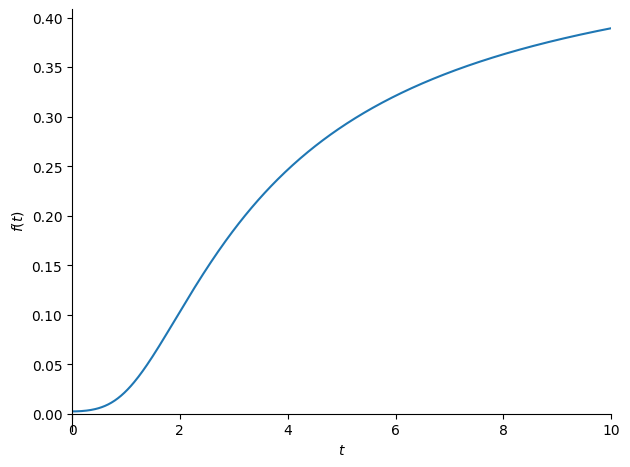

In [11]:
# Fast visualize its shape
smp.plot(P.subs([(m, 1),
                 (a, 1),
                 (L, 2)]), xlim = (0, 10))

In [12]:
# Limit for t approaching to infinity
smp.limit(P, t, smp.oo)

1/2